# Choose seed points, assign demand, run GA and plot networks

In [153]:
import math
import numpy as np
import matplotlib.pyplot as plt
from typing import List
import shapely
from shapely import Polygon, LineString, LinearRing, Point, MultiPoint

## Seed points

Start with a rectangle shape for a city (we'll switch to a real city and street network later), then create a grid of seed points over that shape.

In [2]:
import shapely
from shapely import Polygon, LineString, LinearRing, Point

In [3]:
coords = [(0., 0.), (0., 100.), (100., 100.), (100., 0.)]

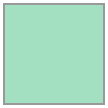

In [4]:
city = Polygon(coords)
city

### Hexagons

The code in this section is inspired by ideas and code from Red Blob Games:
- https://www.redblobgames.com/grids/hexagons/
- https://www.redblobgames.com/grids/hexagons/implementation.html
- https://www.redblobgames.com/grids/parts/

![Hex Sizes](../../red-blob-games/hex_size.png "Hex Sizes")

![Hex Angles](../../red-blob-games/hex_angles.png "Hex Angles")

![Cube Coords](../../red-blob-games/cube_coords.png "Cube Coords")

![Axial Coords](../../red-blob-games/axial_coords.png "Axial Coords")

In [133]:
def hex_corner(centre: shapely.Point, size: float, i: int, pointy: bool) -> shapely.Point:
    """Produces the ith corner of a regular hexagon as a Shapely point.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
        i: Which corner (out of 6).
        pointy: Whether the hexagon should be pointy-top or flat-top.
    
    Returns:
        A shapely.Point representing the ith corner of a hexagon.
    """
    if pointy:
        angle_deg = 60 * (i+1) - 30
    else:
        angle_deg = 60 * i
    angle_rad = np.pi / 180 * angle_deg
    print(f"Point {i}: {angle_deg} degrees")
    return Point(centre.x + size * np.cos(angle_rad),
                 centre.y + size * np.sin(angle_rad))

def hex_corner_flat(centre: shapely.Point, size: float, i: int) -> shapely.Point:
    """Produces the ith corner of a flat-top regular hexagon as a Shapely point.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
        i: Which corner (out of 6).
    
    Returns:
        A shapely.Point representing the ith corner of a hexagon.
    """
    hex_corner(centre, size, i, False)

def hex_corner_pointy(centre: shapely.Point, size: float, i: int) -> shapely.Point:
    """Produces the ith corner of a pointy-top regular hexagon as a Shapely point.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
        i: Which corner (out of 6).
    
    Returns:
        A shapely.Point.
    """
    hex_corner(centre, size, i, True)

In [134]:
def get_hex_vertices(centre: shapely.Point, size: float, pointy: bool) -> List[shapely.Point]:
    """Returns a list of hexagon corners as Shapely points.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
        pointy: Whether the hexagon should be pointy-top or flat-top.
    
    Returns:
        A list of Shapely points.
    """
    coords = []
    for i in range(0,6):
        coords.append(hex_corner(centre, size, i, pointy))
    return coords

In [137]:
# TODO: degrees are increasing counterclockwise,
#    I would rather have them increase clockwise

def create_hexagon(centre: shapely.Point, size: float, pointy: bool, polygon: bool) -> shapely.Polygon:
    """Creates a regular hexagon as a Shapely polygon or curve.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
        pointy: Whether the hexagon should be pointy-top or flat-top.
        as_polygon: Whether the hexagon should be a Shapely Polygon or LinearRing.
    
    Returns:
        A regular hexagon.
    """
    coords = get_hex_vertices(centre, size, pointy)
    if polygon:
        return Polygon(coords)
    else:
        return LinearRing(coords)

Point 0: 30 degrees
Point 1: 90 degrees
Point 2: 150 degrees
Point 3: 210 degrees
Point 4: 270 degrees
Point 5: 330 degrees


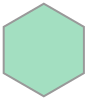

In [138]:
centre_ex = Point(50., 50.)
size_ex = 5

my_hex_poly = create_hexagon(centre_ex, size_ex, True, True)
my_hex_poly

Point 0: 0 degrees
Point 1: 60 degrees
Point 2: 120 degrees
Point 3: 180 degrees
Point 4: 240 degrees
Point 5: 300 degrees


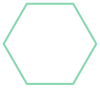

In [139]:
my_hex_line = create_hexagon(centre_ex, size_ex, False, False)
my_hex_line

In [140]:
len(my_hex_line.coords)

7

In [141]:
# Next step... create grid of hexagon vertices over the 'city' shape
# See https://www.redblobgames.com/grids/hexagons/ and https://www.redblobgames.com/grids/hexagons/implementation.html


In a rectangle from (0,0) to (X, Y):

while x<X and y<Y

For pointy
Set height = 2 * size
Set width = sqrt(3) * size

Y-AXIS:

1st col (x=0), and every odd col:
1. Set 1st vertex at y=0.25\*height
2. Set 2nd vertex at y=0.75\*height (increase by 0.5\*height)
3. Set 3rd vertex at y=1.75\height (increase by 1\*height)
So: Start at y=0.25\*height; when i is even, set vertex at y = y + 0.5\*height; when i is odd, set vertex at y = y + 1\*height

2nd col (x=0.5\*width), and every even col:
1. Set 1st vertex at y=0*height
2. Set 2nd vertex at y=1\*height (increase by 1\*height)
3. Set 3rd vertex at y=1.5\height (increase by 0.5\*height)
So: Start at y=0\*height; when i is even, set vertex at y = y + 1\*height; when i is odd, set vertex at y = y + 0.5\*height

X-AXIS:

1st row (y=0):
1. Set 1st vertex at x=0.5\*width
2. Set 2nd vertex at x=1.5\*width (increase by 1\*width)
3. Set 3rd vertex at x=2.5\width (increase by 1\*width)
So: Start at x=0.5\*width; set succeeding vertices at x = x + 1\*width (increase x by 1\*width every time)

2nd row (y=0.25\*height):
1. Set 1st vertex at x=0\*width
2. Set 2nd vertex at x=1\*width (increase by 1\*width)
3. Set 3rd vertex at x=2\width (increase by 1\*width)
So: Start at x=0\*width; set succeeding vertices at x = x + 1\*width (increase x by 1\*width every time)

3rd row: same as 2nd row
4th row: same as 1st row
5th row: same as 1st row
6th row: same as 2nd+3rd row
7th row: same as 2nd+3rd row


POINT (0 7.5)
POINT (0 22.5)
POINT (0 52.5)
POINT (0 67.5)
POINT (0 97.5)


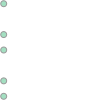

In [154]:
# Try to make just one column first
from shapely import MultiPoint

def create_hex_grid(hex_size: float, Y: float):
    seed_points = []
    hex_height = 2 * hex_size
    # hex_width = math.sqrt(3) * hex_size
    x: float = 0.0
    row: int = 0
    y: float = 0.25 * hex_height
    while y < Y:
        point = (x, y)
        seed_points.append(point)
        if row % 2 == 0:
            y += 0.5 * hex_height
        else:
            y += 1 * hex_height
        row += 1
    return seed_points

seed_points = MultiPoint(create_hex_grid(15.0, 100.0))

for p in list(seed_points.geoms):
    print(p)

seed_points

hex_height: 30.0
hex_width: 25.980762113533157


-----------


Col: 0
x: 0.0
Row: 0
y: 7.5
Point: (0.0, 7.5)


Col: 0
x: 0.0
Row: 1
y: 22.5




-----------


Col: 0
x: 0.0
Row: 1
y: 22.5
Point: (0.0, 22.5)


Col: 0
x: 0.0
Row: 2
y: 52.5




-----------


Col: 0
x: 0.0
Row: 2
y: 52.5
Point: (0.0, 52.5)


Col: 0
x: 0.0
Row: 3
y: 67.5




-----------


Col: 0
x: 0.0
Row: 3
y: 67.5
Point: (0.0, 67.5)


Col: 0
x: 0.0
Row: 4
y: 97.5




-----------


Col: 0
x: 0.0
Row: 4
y: 97.5
Point: (0.0, 97.5)


Col: 0
x: 0.0
Row: 5
y: 112.5




-----------


Col: 2
x: 25.980762113533157
Row: 0
y: 7.5
Point: (25.980762113533157, 7.5)


Col: 2
x: 25.980762113533157
Row: 1
y: 22.5




-----------


Col: 2
x: 25.980762113533157
Row: 1
y: 22.5
Point: (25.980762113533157, 22.5)


Col: 2
x: 25.980762113533157
Row: 2
y: 52.5




-----------


Col: 2
x: 25.980762113533157
Row: 2
y: 52.5
Point: (25.980762113533157, 52.5)


Col: 2
x: 25.980762113533157
Row: 3
y: 67.5




-----------


Col: 2
x: 25.980762113533157


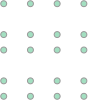

In [195]:
# Now try to make all even columns first

def create_hex_grid_even(hex_size: float, X: float, Y: float):
    seed_points = []
    
    hex_height = 2 * hex_size
    hex_width = math.sqrt(3) * hex_size
    print(f"hex_height: {hex_height}")
    print(f"hex_width: {hex_width}")
    
    col: int = 0
    x: float = 0.0 * hex_width
    while x < X:
        row: int = 0
        y: float = 0.25 * hex_height
        while y < Y:
            point = (x, y)
            print("\n")
            print("-----------")
            print("\n")
            print(f"Col: {col}")
            print(f"x: {x}")
            print(f"Row: {row}")
            print(f"y: {y}")
            print(f"Point: {point}")
            seed_points.append(point)
            if row % 2 == 0:
                y += 0.5 * hex_height
            else:
                y += 1 * hex_height
            row += 1
            print("\n")
            print(f"Col: {col}")
            print(f"x: {x}")
            print(f"Row: {row}")
            print(f"y: {y}")
            print("\n")
        
        x += 1 * hex_width
        col += 2
    return seed_points

points_even = create_hex_grid_even(15.0, 100.0, 100.0)

for p in points_even:
    print(p)

seed_points_even = MultiPoint(points_even)
seed_points_even

hex_height: 30.0
hex_width: 25.980762113533157


-----------


Col: 1
x: 12.990381056766578
Row: 0
y: 0.0
Point: (12.990381056766578, 0.0)


Col: 1
x: 12.990381056766578
Row: 1
y: 30.0




-----------


Col: 1
x: 12.990381056766578
Row: 1
y: 30.0
Point: (12.990381056766578, 30.0)


Col: 1
x: 12.990381056766578
Row: 2
y: 45.0




-----------


Col: 1
x: 12.990381056766578
Row: 2
y: 45.0
Point: (12.990381056766578, 45.0)


Col: 1
x: 12.990381056766578
Row: 3
y: 75.0




-----------


Col: 1
x: 12.990381056766578
Row: 3
y: 75.0
Point: (12.990381056766578, 75.0)


Col: 1
x: 12.990381056766578
Row: 4
y: 90.0




-----------


Col: 1
x: 12.990381056766578
Row: 4
y: 90.0
Point: (12.990381056766578, 90.0)


Col: 1
x: 12.990381056766578
Row: 5
y: 120.0




-----------


Col: 3
x: 38.97114317029973
Row: 0
y: 0.0
Point: (38.97114317029973, 0.0)


Col: 3
x: 38.97114317029973
Row: 1
y: 30.0




-----------


Col: 3
x: 38.97114317029973
Row: 1
y: 30.0
Point: (38.97114317029973, 30.0)


Col: 3
x: 38.

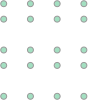

In [196]:
# Odd columns with print statements
def create_hex_grid_odd(hex_size: float, X: float, Y: float):
    seed_points = []
    
    hex_height = 2 * hex_size
    hex_width = math.sqrt(3) * hex_size
    print(f"hex_height: {hex_height}")
    print(f"hex_width: {hex_width}")
    
    col: int = 1
    x: float = 0.5 * hex_width
    while x < X:
        row: int = 0
        y: float = 0.0 * hex_height
        while y < Y:
            point = (x, y)
            print("\n")
            print("-----------")
            print("\n")
            print(f"Col: {col}")
            print(f"x: {x}")
            print(f"Row: {row}")
            print(f"y: {y}")
            print(f"Point: {point}")
            seed_points.append(point)
            if row % 2 == 0:
                y += 1.0 * hex_height
            else:
                y += 0.5 * hex_height
            row += 1
            print("\n")
            print(f"Col: {col}")
            print(f"x: {x}")
            print(f"Row: {row}")
            print(f"y: {y}")
            print("\n")
        
        x += 1 * hex_width
        col += 2
    return seed_points

points_odd = create_hex_grid_odd(15.0, 100.0, 100.0)

for p in points_odd:
    print(p)

seed_points_odd = MultiPoint(points_odd)
seed_points_odd

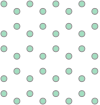

In [198]:
combined_points = points_even + points_odd
combined = MultiPoint(combined_points)
combined

(12.990381056766578, 7.5)
(12.990381056766578, 37.5)
(12.990381056766578, 52.5)
(12.990381056766578, 82.5)
(12.990381056766578, 97.5)
(38.97114317029973, 7.5)
(38.97114317029973, 37.5)
(38.97114317029973, 52.5)
(38.97114317029973, 82.5)
(38.97114317029973, 97.5)
(64.95190528383289, 7.5)
(64.95190528383289, 37.5)
(64.95190528383289, 52.5)
(64.95190528383289, 82.5)
(64.95190528383289, 97.5)
(90.93266739736605, 7.5)
(90.93266739736605, 37.5)
(90.93266739736605, 52.5)
(90.93266739736605, 82.5)
(90.93266739736605, 97.5)


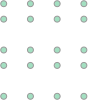

In [181]:
# Now try to make all odd columns
def create_hex_grid(hex_size: float, X: float, Y: float):
    seed_points = []
    
    hex_height = 2 * hex_size
    hex_width = math.sqrt(3) * hex_size
    
    col: int = 1
    x: float = 0.5 * hex_width
    while x < X:
        row: int = 0
        y: float = 0.25 * hex_height
        while y < Y:
            point = (x, y)
            seed_points.append(point)
            if row % 2 == 0:
                y += 1 * hex_height
            else:
                y += 0.5 * hex_height
            row += 1
        
        x += 1 * hex_width
        col += 1
    return seed_points

points = create_hex_grid(15.0, 100.0, 100.0)

for p in points:
    print(p)

seed_points_odd = MultiPoint(points)
seed_points_odd

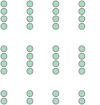

In [191]:
combined = seed_points_even.union(seed_points_odd)
combined

(0.0, 7.0)
(0.0, 21.0)
(0.0, 49.0)
(0.0, 63.0)
(0.0, 91.0)
(24.24871130596428, 0.0)
(24.24871130596428, 28.0)
(24.24871130596428, 42.0)
(24.24871130596428, 70.0)
(24.24871130596428, 84.0)
(48.49742261192856, 7.0)
(48.49742261192856, 21.0)
(48.49742261192856, 49.0)
(48.49742261192856, 63.0)
(48.49742261192856, 91.0)
(72.74613391789285, 0.0)
(72.74613391789285, 28.0)
(72.74613391789285, 42.0)
(72.74613391789285, 70.0)
(72.74613391789285, 84.0)
(96.99484522385713, 7.0)
(96.99484522385713, 21.0)
(96.99484522385713, 49.0)
(96.99484522385713, 63.0)
(96.99484522385713, 91.0)
4.123930494211613
3.5714285714285716


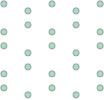

In [178]:
# Now try to make all columns
def create_hex_grid(hex_size: float, X: float, Y: float):
    seed_points = []
    
    hex_height = 2 * hex_size
    hex_width = math.sqrt(3) * hex_size
    
    col: int = 0
    x: float = 0.0
    while x < X:
        row: int = 0
        if col % 2 == 0:
            y: float = 0.25 * hex_height
            while y < Y:
                point = (x, y)
                seed_points.append(point)
                if row % 2 == 0:
                    y += 0.5 * hex_height
                else:
                    y += 1 * hex_height
                row += 1
        else:
            y: float = 0.0 * hex_height
            while y < Y:
                point = (x, y)
                seed_points.append(point)
                if row % 2 == 1:
                    y += 0.5 * hex_height
                else:
                    y += 1 * hex_height
                row += 1
            
        x += 1 * hex_width
        col += 1
    return seed_points

points = create_hex_grid(14.0, 100.0, 100.0)
shapely_points = []

for p in points:
    print(p)
    shapely_points.append(Point(p))

seed_points = MultiPoint(points)
print(100/(math.sqrt(3)*14))
print(100/(2*14))

seed_points
